# The Hurst phenomenon: persistence, long-range correlations, self-similarity, fractality, and all that...

**Data:**  
MPILMBB EEG microstate sequences (EC, K=4, smoothing='b3')

**Aim:**
The Hurst phenomenon: finding a Hurst exponent of $H > 0.5$. 

**Method(s):**
- **Partiton method** (`mstsa.randomwalk` and `mstsa.dfa`): partition the available microstates into two classes and map each class to -1, +1, respectively; construct the random walk and compute the Hurst exponent via DFA 
  microstate's binary indicator sequence, returning one Hurst exponent per state.
- **One-hot Hurst exponent** (`mstsa.hurst_exponents_dfa`): compute the binary indicator sequence for each microstate class, resulting in K binary sequences, construct the random walk and compute the Hurst exponent via DFA

Computing the Hurst exponent is the easy part and obtaining $H>0.5$ from biological signals is common.  
The difficult part is interpretation:
- Certain carefully designed stochastic processes can be constructed based using $H$ as the only parameter. A famous example is fractional Gaussian noise (fGn) and its integral (or random walk) fractional Brownian motion (fBm). These processes show *other* interesting properties such as long-range correlations (infinite integral over the autocorrelation function); self-similarity (but only in the *statistical* sense, *not strict* self-similarity in the literal sense); fractality (a time series with a non-integer Hausdorff dimension). These properties are built in by construction, they don't come for free with an empirical Hurst exponent H>0.5 from real data.
- Finding a __Hurst exponent H>0.5 does not imply any of the aforementioned properties__, counterexamples abund.
- __Persistence__ is the most careful interpretation/verbalization of H>0.5, ongoing autocorrelations across several time scales of _some kind_ 
- The key to interpretation lies in the method that has been used to calculate the Hurst exponent, two common ones being Detrended Fluctuation Analysis (DFA) or its analogue using wavelets. Importantly, both only measure whether the signal produces variance at a given scale. There is no analysis as to whether:
  - the variance is generated by exactly the same mechanism at each scale,
  - the signal fulfills any similarity criteria across scales (self-similarity), 
  - the marginal density at a single time point looks alike at different scales, in agreement with the Hurst exponent (density scaling) 
- Any process composed of different time scales is likely to yield H>0.5. Therefore, scale-rich processes are just as likely to yield H>0.5 as (some) scale-free processes. It is therefore unjustified to infer scale-freeness from H>0.5

Some of these thoughts will be further illustrated in this notebook.

In [26]:
import os
import glob
import re
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy.stats import pearsonr, spearmanr, shapiro, ttest_rel, wilcoxon
import mstsa

print(f"mstsa version: {mstsa.__version__}")

mstsa version: 0.4.0


In [42]:
data_path = "../data/mpilmbb"
fs = 250          # Hz (4 ms / sample)
smoothing = 'b3'  # smoothing level
K = 4             # single clustering solution, no cross-K comparison
p_scale = dict(lmin=20, lmax=5000, fitmin=20, fitmax=5000, nsteps=30)

pattern = f"{data_path}/*_EC_ms_{smoothing}_K{K}_ep00.npy"
subjects = sorted(re.match(r'(sub-\d+)_', os.path.basename(f)).group(1)
                   for f in glob.glob(pattern))
print(f"{len(subjects)} subjects with EC, smoothing={smoothing!r}, K={K}")

201 subjects with EC, smoothing='b3', K=4


## Fractional Gaussian noise (fGn) simulator

**Aim:**  
Play with fractional Gaussian noise (fGn) to get an idea how the mathematical prototype of a long-range dependent (LRD), fractal, scale-free stochastic process looks like and how H tunes these properties.
- H=0.5: uncorrelated white noise
- 0.5 < H < 1.0: LRD with infinite autocorrelation; make the process as long as you like, it will never go flat, it will continue generating variance at every scale. Since the same statistical law generates the variance at every scale _by construction_, the process displays statistical self-similarity.

**Method:**  
`fGn(H, n)` synthesizes a fractional Gaussian noise trace with a prescribed Hurst
exponent `H` via the Davies & Harte (1987) circulant-embedding method.  
Note:  not part of `mstsa`

In [28]:
def fGn(H, n):
    """Synthesize fractional Gaussian noise (fGn) with Hurst exponent H.

    0 < H <= 1: fractional Gaussian noise with Hurst index H.
    1 < H <= 2: fractional Brownian motion with Hurst index H-1 (the fGn
    increments are cumulatively summed before being returned).
    Either way, power spectral density is proportional to 1/f^(2H-1).

    Davies & Harte (1987) circulant-embedding method; adapted from `fGn` in
    `eeglib3.py` (FvW, 11/2013). See also Beran (1994); Bardet et al. (2002).

    Parameters
    ----------
    H : float
        Hurst exponent.
    n : int
        Number of samples.

    Returns
    -------
    y : ndarray, shape (n,)
        Fractional Gaussian noise (or fBm, if H > 1) sample.
    """
    if H > 1:
        H -= 1
    if H == 0.5:
        y = np.random.randn(n)
    else:
        nfft = int(2 ** np.ceil(np.log2(2 * (n - 1))))
        nfft2 = nfft // 2
        k = np.concatenate([np.arange(nfft2), np.arange(nfft2, 0, -1)])
        Zmag = 0.5 * ((k + 1) ** (2 * H) - 2 * k ** (2 * H) + np.abs(k - 1) ** (2 * H))
        Zmag = np.real(np.fft.fft(Zmag))
        if np.any(Zmag < 0):
            print("Negative values in the FFT of the circulant cov.")
        Zmag = np.sqrt(Zmag)
        Z = Zmag * (np.random.randn(nfft) + 1j * np.random.randn(nfft))
        y = np.real(np.fft.ifft(Z)) * np.sqrt(nfft)
        y = y[:n]
    if H > 1:
        y = np.cumsum(y)
    return y

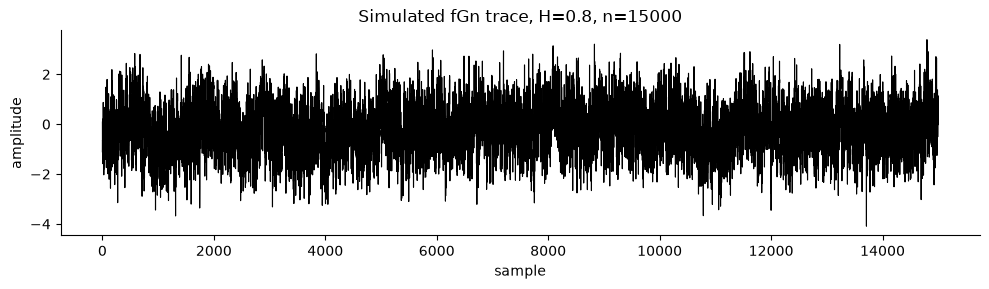

In [29]:
H_demo = 0.8      # Hurst exponent to simulate (0 < H <= 1 for fGn, 1 < H <= 2 for fBm)
n_demo = 15000     # number of samples

x_demo = fGn(H_demo, n_demo)

fig, ax = plt.subplots(figsize=(10, 3))
ax.plot(x_demo, '-k', lw=0.8)
ax.set_xlabel('sample')
ax.set_ylabel('amplitude')
ax.set_title(f'Simulated {"fBm" if H_demo > 1 else "fGn"} trace, '
             f'H={H_demo}, n={n_demo}')
ax.spines[['top', 'right']].set_visible(False)
plt.tight_layout()
plt.show()

## Global field power (GFP)

**Aim:**  
- Now, compare fGn with example GFP time courses from the LEMON database (eyes-closed resting-state EEG)
- The 16 recordings in the figure below all show multiple time scales across the 1 minute recording.
- Variance is produced at many different time scales reaching the total length of the recording. Without any further knowledge about the statistics of the process, **H>0.5 can be predicted**.
- The observed fluctuations in total EEG power are most likely changes in vigilance and arousal levels (many people fall asleep during the resting-state), slow synaptic modulation etc.; each of these processes comes with its own biologically defined time scale. 
- The recordings below are **scale-rich, not scale-free**
- It seems plausible that these slow modulations are reflected in microstate dynamics as well, explaining H>0.5
- Assuming self-similarity - that the same process produces millisecond - second - minute fluctuations is a bold claim that cannot be proved by computing a simple Hurst exponent that can only measure whether **something** produces variance at each scale. 

The same alpha power / GFP comparison for 16 further example subjects (8 x 2 grid):

![Occipital alpha power (O1/O2 analytic amplitude) and GFP for 16 example subjects](figures/occipital_alpha_gfp_examples_grid.png)

## Hurst exponents from partitions and one-hot encoding

The one-hot decomposition used throughout this notebook is not the only way to turn
a `K`-state microstate sequence into a Hurst exponent. The earlier approach of Van De
Ville, Britz & Michel (2010), *PNAS* 107(42), 18179-18184, instead collapses the
sequence into a *binary* `+-1` random walk via a bipartition of the `K` labels
(`mstsa.partitions`/`mstsa.randomwalk`) and estimates `H` from that random walk's DFA
scaling (`mstsa.dfa`), one `H` per partition rather than one per state. For `K=4`
there are 3 distinct bipartitions (`[[0,1],[2,3]]`, `[[0,2],[1,3]]`, `[[0,3],[1,2]]`),
giving 3 partition-based `H` values per subject, compared against the 4 one-hot `H_k`
values from `mstsa.hurst_exponents_dfa`.

For `n_subjects_sample` randomly chosen subjects (fixed seed; this same selection is
reused below in "Slow exponential dynamics"), both sets of exponents are computed and
plotted side by side to see whether the two ways of reducing a categorical sequence
to a scalar random walk agree.

In [30]:
n_subjects_sample = 10
rng_slow = np.random.default_rng(0)
sample_subjects = sorted(rng_slow.choice(subjects, size=n_subjects_sample, replace=False))
print(f"{n_subjects_sample} subjects sampled: {sample_subjects}")

10 subjects sampled: [np.str_('sub-010005'), np.str_('sub-010016'), np.str_('sub-010023'), np.str_('sub-010046'), np.str_('sub-010067'), np.str_('sub-010075'), np.str_('sub-010191'), np.str_('sub-010227'), np.str_('sub-010272'), np.str_('sub-010321')]


In [ ]:
partitions_K = mstsa.partitions(K)
n_partitions = len(partitions_K)
print(f"K={K} bipartitions: {partitions_K}")

cache_dir_compare = "../data/cache/hurst_partition_vs_onehot"
os.makedirs(cache_dir_compare, exist_ok=True)
cache_file_compare = os.path.join(
    cache_dir_compare,
    f"h_onehot_vs_partition_{smoothing}_K{K}_n{n_subjects_sample}"
    f"_lmax{p_scale['lmax']}.npz")

if os.path.exists(cache_file_compare):
    d = np.load(cache_file_compare)
    h_onehot_sample = d['h_onehot_sample']
    h_partition_sample = d['h_partition_sample']
    print(f"loaded cached results from {cache_file_compare}")
else:
    h_onehot_sample = np.zeros((n_subjects_sample, K))
    h_partition_sample = np.zeros((n_subjects_sample, n_partitions))

    for i, subj in enumerate(sample_subjects):
        fname = f"{data_path}/{subj}_EC_ms_{smoothing}_K{K}_ep00.npy"
        x = np.load(fname)

        h_onehot_sample[i] = mstsa.hurst_exponents_dfa(x, **p_scale)

        for j, part in enumerate(partitions_K):
            r = mstsa.randomwalk(x, part)
            h_partition_sample[i, j] = mstsa.dfa(r, **p_scale)

        print(f"[{i+1}/{n_subjects_sample}] {subj}", end="\r")
    print()

    print("done.")
    np.savez(cache_file_compare, h_onehot_sample=h_onehot_sample,
             h_partition_sample=h_partition_sample)

K=4 bipartitions: [[[0, 1], [2, 3]], [[0, 2], [1, 3]], [[0, 3], [1, 2]]]
loaded cached results from ../data/cache/hurst_partition_vs_onehot/h_onehot_vs_partition_b3_K4_n10_lmax10000.npz


In [32]:
rows = []
for i, subj in enumerate(sample_subjects):
    row = {'subject': subj}
    for k in range(K):
        row[f'H_onehot_MS{k}'] = h_onehot_sample[i, k]
    for j in range(n_partitions):
        row[f'H_part_{j}'] = h_partition_sample[i, j]
    row['onehot_mean'] = h_onehot_sample[i].mean()
    row['partition_mean'] = h_partition_sample[i].mean()
    rows.append(row)

df_compare = pd.DataFrame(rows)
print(df_compare.to_string(index=False, float_format=lambda v: f'{v:.3f}'))

print(f"\nOverall mean one-hot H   = {h_onehot_sample.mean():.4f} "
      f"(SD {h_onehot_sample.std(ddof=1):.4f})")
print(f"Overall mean partition H = {h_partition_sample.mean():.4f} "
      f"(SD {h_partition_sample.std(ddof=1):.4f})")

   subject  H_onehot_MS0  H_onehot_MS1  H_onehot_MS2  H_onehot_MS3  H_part_0  H_part_1  H_part_2  onehot_mean  partition_mean
sub-010005         0.585         0.632         0.648         0.672     0.660     0.620     0.650        0.634           0.643
sub-010016         0.658         0.590         0.596         0.553     0.599     0.608     0.602        0.599           0.603
sub-010023         0.565         0.604         0.571         0.587     0.602     0.546     0.595        0.582           0.581
sub-010046         0.587         0.572         0.586         0.526     0.595     0.536     0.569        0.568           0.567
sub-010067         0.699         0.654         0.705         0.705     0.651     0.715     0.701        0.691           0.689
sub-010075         0.698         0.768         0.732         0.762     0.800     0.723     0.721        0.740           0.748
sub-010191         0.708         0.680         0.669         0.671     0.694     0.642     0.697        0.682         

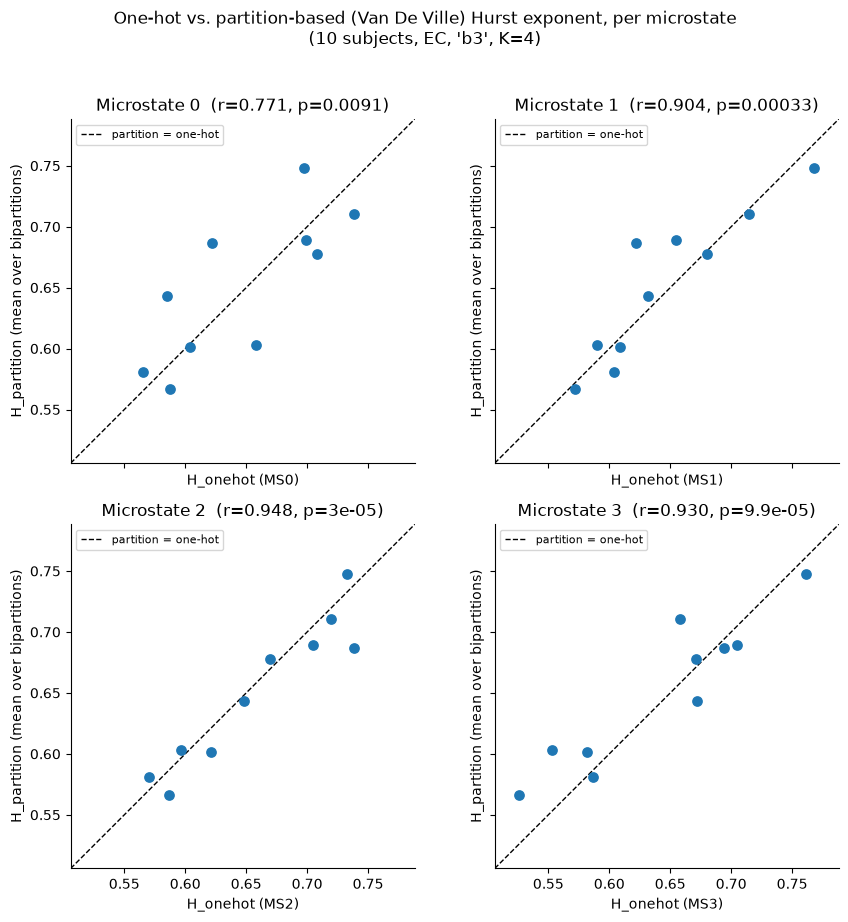

In [33]:
partition_mean_sample = h_partition_sample.mean(axis=1)  # (n_subjects_sample,)

lims = (min(h_onehot_sample.min(), partition_mean_sample.min()) - 0.02,
        max(h_onehot_sample.max(), partition_mean_sample.max()) + 0.02)

n_cols = 2
n_rows = -(-K // n_cols)  # ceil
fig, axes = plt.subplots(n_rows, n_cols, figsize=(4.5 * n_cols, 4.5 * n_rows),
                          sharex=True, sharey=True)
axes_flat = np.atleast_1d(axes).flatten()

for k, ax in enumerate(axes_flat[:K]):
    x_vals = h_onehot_sample[:, k]
    y_vals = partition_mean_sample
    r, p = pearsonr(x_vals, y_vals)

    ax.scatter(x_vals, y_vals, s=45, color='tab:blue', zorder=3)
    ax.plot(lims, lims, 'k--', lw=1, label='partition = one-hot')
    ax.set_xlim(lims)
    ax.set_ylim(lims)
    ax.set_aspect('equal')
    ax.set_title(f'Microstate {k}  (r={r:.3f}, p={p:.2g})')
    ax.set_xlabel(f'H_onehot (MS{k})')
    ax.set_ylabel('H_partition (mean over bipartitions)')
    ax.spines[['top', 'right']].set_visible(False)
    ax.legend(fontsize=8, loc='upper left')

for ax in axes_flat[K:]:
    ax.set_visible(False)

fig.suptitle(f'One-hot vs. partition-based (Van De Ville) Hurst exponent, per microstate\n'
             f'({n_subjects_sample} subjects, EC, {smoothing!r}, K={K})', y=1.02)
plt.tight_layout()
os.makedirs('figures', exist_ok=True)
plt.savefig('figures/hurst_onehot_vs_partition.png', dpi=150, bbox_inches='tight')
plt.show()

## Slow exponential dynamics?

A simple mechanism for persistence (H>0.5) is an exponentially (i.e. short-range) correlated process with a time constant that is large relative to the length of the recording.  

We investigated this mechanism in: von Wegner, F., Tagliazucchi, E., Brodbeck, V., & Laufs, H. (2016), "Analytical and empirical fluctuation functions of the EEG microstate random walk --
Short-range vs. long-range correlations", *NeuroImage*, 141, 442-451.

Method: for each microstate sequence, generate first-order Markov surrogates (exponential autocorrelations) with the same time constant as the real microstate sequence and construct a Hurst exponent confidence interval.

- for `n_subjects_sample` randomly chosen subjects (fixed seed) and each of their `K`
microstates, `n_surr_slow` first-order Markov surrogates are synthesized matched to
that subject's own transition matrix and stationary distribution
(`mstsa.tpm_cond`/`mstsa.pmf`/`mstsa.mc_sample_path`), and the one-hot DFA Hurst
exponent (`mstsa.hurst_exponents_dfa`) is computed for both the real sequence and
each surrogate.

**Interpretation:**
A first-order Markov surrogate is exactly memoryless beyond one step by construction,
so its Hurst exponent reflects only whatever apparent scaling behavior a
first-order Markov chain with the subject's own transition statistics can produce.  
The code applies a one-sided non-parametric test. Accepting the alternative hypothesis `H_real > H_surrogate`, might indicate genuine LRD, but also other mechanisms such as non-stationarities.  
p-value: `p = (1 + #surrogates >= H_real) / (n_surr_slow + 1)`  
The smallest achievable p-value is `1/(n_surr_slow + 1)`, so `n_surr_slow` is set to 19.

In [34]:
n_surr_slow = 19  # smallest count giving a one-sided rank-test floor of 1/20 = 0.05

cache_dir_slow = "../data/cache/slow_exponential_dynamics"
os.makedirs(cache_dir_slow, exist_ok=True)
cache_file_slow = os.path.join(
    cache_dir_slow,
    f"h_real_vs_surr_{smoothing}_K{K}_n{n_subjects_sample}_nsurr{n_surr_slow}_lmax{p_scale['lmax']}.npz")

if os.path.exists(cache_file_slow):
    d = np.load(cache_file_slow)
    h_real_slow = d['h_real_slow']
    h_surr_slow = d['h_surr_slow']
    n_samples_slow = d['n_samples_slow']
    sample_subjects = list(d['sample_subjects'])
    print(f"loaded cached results from {cache_file_slow}")
else:
    h_real_slow = np.zeros((n_subjects_sample, K))
    h_surr_slow = np.zeros((n_subjects_sample, n_surr_slow, K))
    n_samples_slow = np.zeros(n_subjects_sample, dtype=int)

    for i, subj in enumerate(sample_subjects):
        fname = f"{data_path}/{subj}_EC_ms_{smoothing}_K{K}_ep00.npy"
        x = np.load(fname)
        nx = len(x)
        n_samples_slow[i] = nx

        h_real_slow[i] = mstsa.hurst_exponents_dfa(x, **p_scale)

        # first-order Markov surrogate matched to this subject's own transition
        # matrix and stationary distribution
        T = mstsa.tpm_cond(x, K)
        p = mstsa.pmf(x, K)
        for j in range(n_surr_slow):
            surr = mstsa.mc_sample_path(T=T, n=nx, p=p)
            h_surr_slow[i, j] = mstsa.hurst_exponents_dfa(surr, **p_scale)

        print(f"[{i+1}/{n_subjects_sample}] {subj}", end="\r")
    print()

    print("done.")
    np.savez(cache_file_slow, h_real_slow=h_real_slow, h_surr_slow=h_surr_slow,
             n_samples_slow=n_samples_slow, sample_subjects=np.array(sample_subjects))

loaded cached results from ../data/cache/slow_exponential_dynamics/h_real_vs_surr_b3_K4_n10_nsurr19_lmax10000.npz


In [35]:
alpha_slow = 0.05

rows = []
pretty_rows = []
for i, subj in enumerate(sample_subjects):
    for k in range(K):
        real = h_real_slow[i, k]
        surr_vals = h_surr_slow[i, :, k]
        # one-sided rank-based surrogate test (Theiler et al.-style): is H_real
        # unusually HIGH relative to its own surrogates, not just "different"
        n_ge = int(np.sum(surr_vals >= real))
        p_one_sided = (1 + n_ge) / (n_surr_slow + 1)
        significant = bool(p_one_sided <= alpha_slow)
        ci_lo, ci_hi = np.percentile(surr_vals, [2.5, 97.5])

        rows.append(dict(subject=subj, state=k, H_real=real,
                          surr_mean=surr_vals.mean(), surr_std=surr_vals.std(ddof=1),
                          surr_max=surr_vals.max(), p_one_sided=p_one_sided,
                          significant=significant))
        pretty_rows.append({
            'subject': f'{subj} (MS{k})',
            'H_real': f'{real:.3f}',
            'surrogate H, mean (95% CI)': f'{surr_vals.mean():.3f} ({ci_lo:.3f}; {ci_hi:.3f})',
            'p (one-sided)': f'{p_one_sided:.3f}{"*" if significant else ""}',
        })

df_slow = pd.DataFrame(rows)
df_pretty = pd.DataFrame(pretty_rows)
print(df_pretty.to_string(index=False))
print(f"\n* p<={alpha_slow} (one-sided rank test; minimum achievable p = "
      f"1/{n_surr_slow + 1} = {1 / (n_surr_slow + 1):.3f})")
print(f"{df_slow['significant'].sum()}/{len(df_slow)} (subject, state) pairs show "
      f"H_real significantly higher than the {n_surr_slow} first-order Markov surrogates")

print(f"\nHow often was each microstate's H_real significantly higher than its "
      f"{n_surr_slow} first-order Markov surrogates, out of {n_subjects_sample} subjects:")
print(f"{'state':>6s} {'n_sig':>7s} {'fraction':>9s}")
for k in range(K):
    n_sig = int(df_slow.loc[df_slow['state'] == k, 'significant'].sum())
    print(f"{k:6d} {n_sig:4d}/{n_subjects_sample:<3d} {n_sig / n_subjects_sample:9.2%}")

         subject H_real surrogate H, mean (95% CI) p (one-sided)
sub-010005 (MS0)  0.585       0.611 (0.557; 0.665)         0.800
sub-010005 (MS1)  0.632       0.606 (0.572; 0.633)         0.200
sub-010005 (MS2)  0.648       0.612 (0.567; 0.657)         0.150
sub-010005 (MS3)  0.672       0.614 (0.556; 0.656)        0.050*
sub-010016 (MS0)  0.658       0.624 (0.548; 0.686)         0.200
sub-010016 (MS1)  0.590       0.618 (0.551; 0.649)         0.900
sub-010016 (MS2)  0.596       0.620 (0.598; 0.654)         1.000
sub-010016 (MS3)  0.553       0.619 (0.564; 0.677)         1.000
sub-010023 (MS0)  0.565       0.621 (0.578; 0.667)         1.000
sub-010023 (MS1)  0.604       0.623 (0.595; 0.664)         0.850
sub-010023 (MS2)  0.571       0.616 (0.557; 0.656)         0.900
sub-010023 (MS3)  0.587       0.623 (0.574; 0.661)         0.900
sub-010046 (MS0)  0.587       0.612 (0.563; 0.651)         0.800
sub-010046 (MS1)  0.572       0.635 (0.591; 0.671)         1.000
sub-010046 (MS2)  0.586  

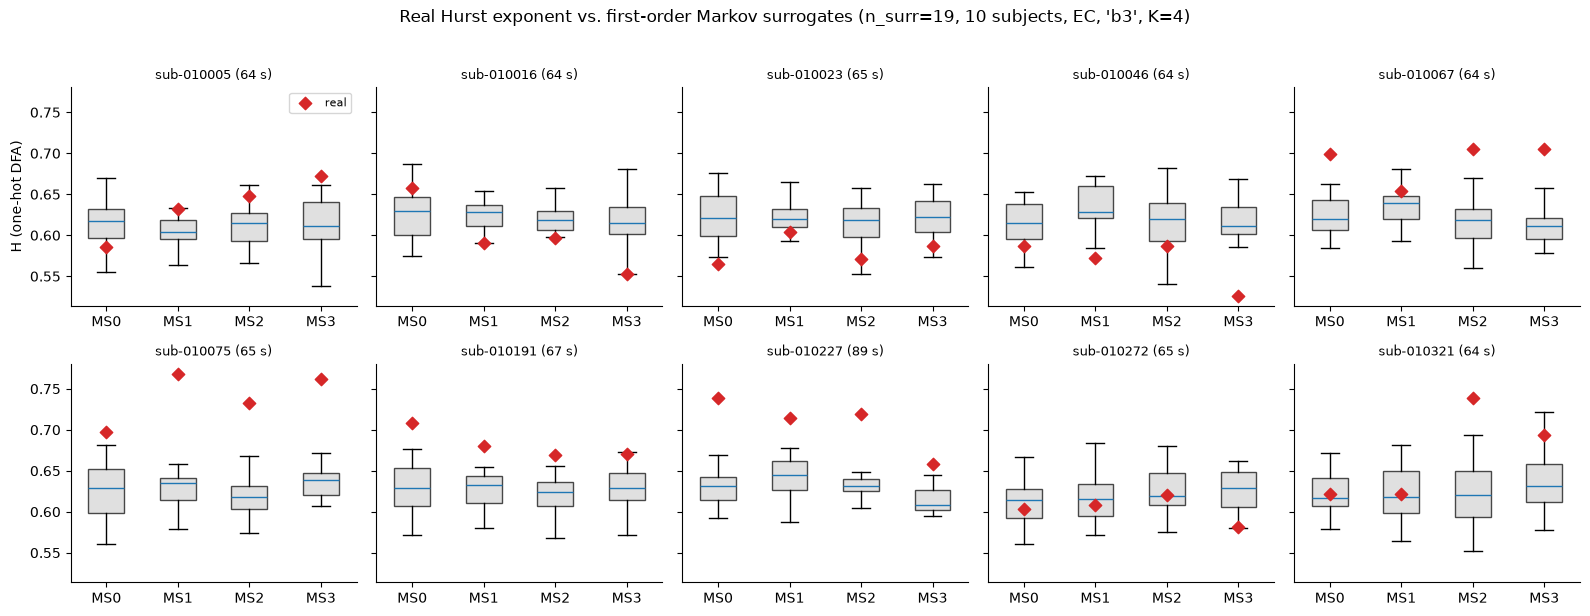

In [36]:
n_cols = 5
n_rows = -(-n_subjects_sample // n_cols)  # ceil
fig, axes = plt.subplots(n_rows, n_cols, figsize=(3.2 * n_cols, 3 * n_rows), sharey=True)
axes_flat = np.atleast_1d(axes).flatten()

for i, subj in enumerate(sample_subjects):
    ax = axes_flat[i]
    for k in range(K):
        ax.boxplot([h_surr_slow[i, :, k]], positions=[k], widths=0.5, showfliers=False,
                   patch_artist=True, boxprops=dict(facecolor='lightgray', alpha=0.7),
                   medianprops=dict(color='tab:blue'))
    ax.scatter(range(K), h_real_slow[i], color='tab:red', marker='D', s=40, zorder=5,
               label='real')
    ax.set_xticks(range(K))
    ax.set_xticklabels([f'MS{k}' for k in range(K)])
    ax.set_title(f'{subj} ({n_samples_slow[i] / fs:.0f} s)', fontsize=9)
    ax.spines[['top', 'right']].set_visible(False)
    if i == 0:
        ax.legend(fontsize=8)

for ax in axes_flat[n_subjects_sample:]:
    ax.set_visible(False)

axes_flat[0].set_ylabel('H (one-hot DFA)')

fig.suptitle(f'Real Hurst exponent vs. first-order Markov surrogates '
             f'(n_surr={n_surr_slow}, {n_subjects_sample} subjects, EC, {smoothing!r}, K={K})',
             y=1.02)
plt.tight_layout()
os.makedirs('figures', exist_ok=True)
plt.savefig('figures/slow_exponential_dynamics.png', dpi=150, bbox_inches='tight')
plt.show()

## Sojourn-time distribution fit - searching for powerlaws

One way that a binary stochastic process can generate true LRD is when the states have powerlaw-distributed sojourn times ('microstate durations'), p(τ) ~ τ^{−α}.  
According to Taqqu–Willinger–Sherman (1997), an alternating-renewal-process with such a sojourn time pdf, and 2 < α < 3 (finite mean, infinite variance), has an aggregated process (random walk) that converges to fractional Gaussian noise with
$$
H = (4 − α)/2.
$$
This only holds for 2 < α < 3 (giving H ∈ (0.5, 1).
This is sometimes written using the tail's survival exponent μ = α − 1, so H = (3 − μ)/2.

Let's test whether empirical microstate sojourn times are powerlaw-distributed?
The following distributions are considered:
- powerlaw
- exponential 
- stretched exponential (Weibull)
- lognormal

The code uses the amazing powerlaw package by Newman and Shalizi. Note that the plot shows the CCDF which has exponent μ = α − 1. 

For each microstate, sojourn-time (dwell-time) durations are pooled across all
`{len(subjects)}` subjects (`mstsa.sojourn_times_unordered`, same EC/`smoothing`/`K`
selection as above), then a power law is fit together with three alternative
distributions -- exponential, stretched exponential (Weibull), and lognormal -- using
the Clauset et al. (2009) maximum-likelihood method from the `powerlaw` package, the
same method `mstsa.sojourn_distribution_fit` uses internally. `sojourn_distribution_fit`
itself only fits a *single* sequence's own sojourns, so getting the *population-level*
pooled fit shown here requires pooling durations across subjects first (via
`mstsa.sojourn_times_unordered`), then fitting the pooled distribution with the same
`powerlaw`-based method.

Each alternative is contrasted against the power-law null with a log-likelihood-ratio
test (`Fit.distribution_compare`): positive `R` favors the power law, negative `R`
favors the alternative; `p` is the two-sided significance of that preference.

In [ ]:
import pickle
import powerlaw as pl

alt_distributions = ('exponential', 'stretched_exponential', 'lognormal')

cache_dir_sojourn = "../data/cache/sojourn_distribution_fit"
os.makedirs(cache_dir_sojourn, exist_ok=True)
cache_file_sojourn = os.path.join(cache_dir_sojourn, f"pooled_fits_ms_{smoothing}_K{K}.pkl")

if os.path.exists(cache_file_sojourn):
    with open(cache_file_sojourn, 'rb') as fh:
        fits = pickle.load(fh)
    print(f"loaded cached fits from {cache_file_sojourn}")
else:
    # Pool sojourn-time durations per microstate across all subjects: mstsa extracts
    # each subject's own sojourns, but mstsa.sojourn_distribution_fit only fits a
    # single sequence at a time, so the cross-subject pooling happens here first.
    pooled_durations = [[] for _ in range(K)]
    for subj in subjects:
        fname = f"{data_path}/{subj}_EC_ms_{smoothing}_K{K}_ep00.npy"
        x = np.load(fname)
        durations_per_symbol = mstsa.sojourn_times_unordered(x, K)
        for k in range(K):
            pooled_durations[k].extend(durations_per_symbol[k])

    # Fit power law + alternatives to each state's pooled sojourn-time distribution,
    # via the same Clauset et al. (2009) MLE method mstsa.sojourn_distribution_fit
    # uses internally (the `powerlaw` package). Durations are converted from
    # samples to milliseconds (1 sample = 1000/fs ms) before fitting -- fs=250 Hz
    # makes this an exact x4 integer scaling, so the discrete fit is unaffected.
    fits = []
    for k in range(K):
        y = np.asarray(pooled_durations[k], dtype=float) * (1000.0 / fs)
        fit = pl.Fit(y, discrete=True, verbose=False)
        fits.append(fit)

    with open(cache_file_sojourn, 'wb') as fh:
        pickle.dump(fits, fh)

print(f"{'state':>6s} {'n_pooled':>9s} {'xmin (ms)':>9s} {'n_tail':>7s} {'alpha':>7s}")
for k in range(K):
    fit = fits[k]
    n_pooled = len(fit.data_original)
    n_tail = int(np.sum(fit.data_original >= fit.xmin))
    print(f"{k:6d} {n_pooled:9d} {fit.xmin:9.1f} {n_tail:7d} {fit.power_law.alpha:7.3f}")

print(f"\n{'state':>6s} {'alt. distribution':>22s} {'LLR (R)':>9s} {'p':>10s}  favors")
for k in range(K):
    fit = fits[k]
    for name in alt_distributions:
        R, p = fit.distribution_compare('power_law', name, normalized_ratio=True)
        favors = 'power law' if R > 0 else name.replace('_', ' ')
        print(f"{k:6d} {name:>22s} {R:+9.3f} {p:10.3g}  {favors}")


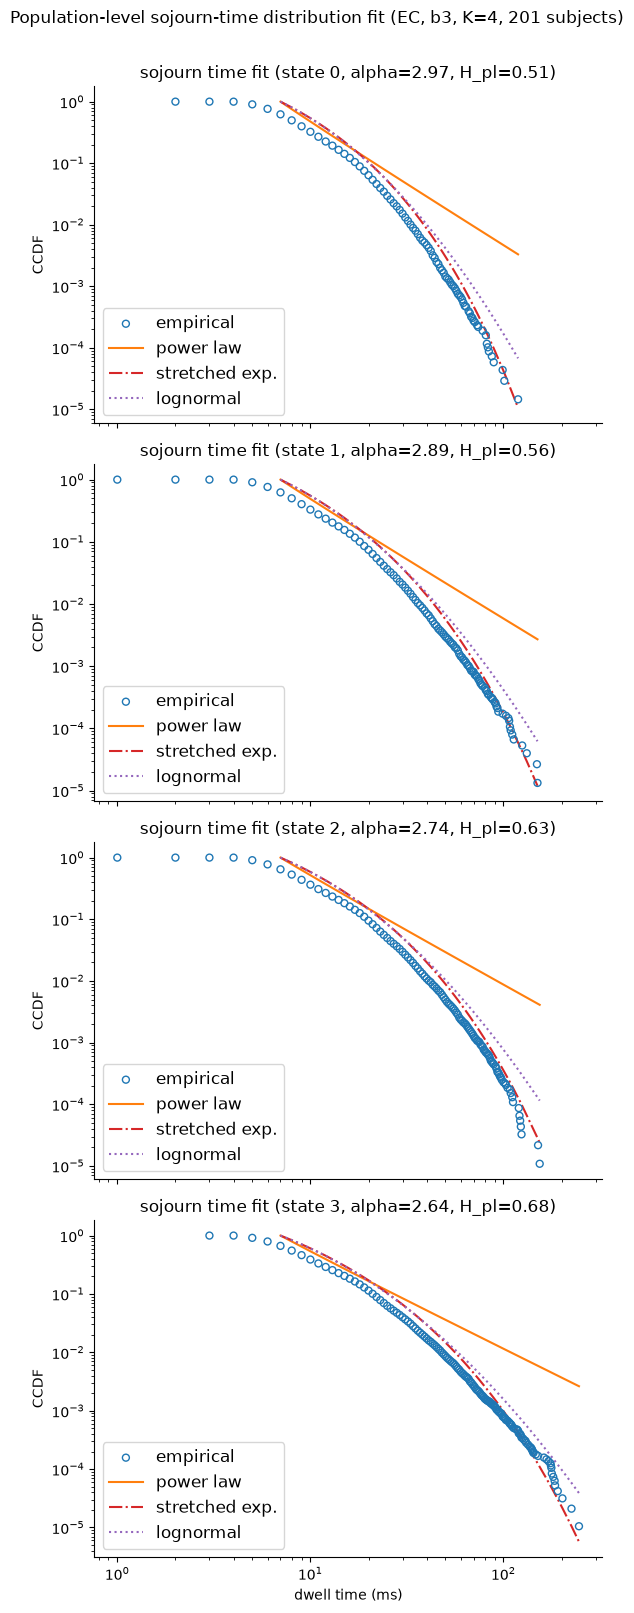

In [41]:
def alpha_to_hurst(alpha):
    """Theoretical H implied by a power-law sojourn-time tail exponent alpha,
    via the Taqqu-Willinger-Sherman (1997) alternating-renewal-process result
    H = (4 - alpha) / 2, valid only for 2 < alpha < 3 (finite mean, infinite
    variance); returns nan outside that range rather than extrapolating."""
    if 2 < alpha < 3:
        return (4 - alpha) / 2
    return np.nan


dist_colors = {'power_law': 'tab:orange', 
               'exponential': 'tab:green',
               'stretched_exponential': 'tab:red', 
               'lognormal': 'tab:purple'}
dist_linestyles = {'power_law': '-', 
                   'exponential': '--',
                   'stretched_exponential': '-.', 
                   'lognormal': ':'}
dist_labels = {'power_law': 'power law', 
               'exponential': 'exponential',
               'stretched_exponential': 'stretched exp.', 
               'lognormal': 'lognormal'}

# Which fitted distributions to draw, in addition to the empirical CCDF; 
# e.g. drop 'exponential' from this list if its curve distorts the axes at 
# these scales.
dists_to_plot = ('power_law', 
                 #'exponential', 
                 'stretched_exponential', 
                 'lognormal')
alt_dists_to_plot = [name for name in alt_distributions if name in dists_to_plot]

fig, axes = plt.subplots(K, 1, figsize=(6, 4 * K), sharex=True)

for k, ax in enumerate(axes):
    fit = fits[k]
    alpha_k = fit.power_law.alpha
    h_pl_k = alpha_to_hurst(alpha_k)

    x_emp, ccdf_emp = fit.ccdf(original_data=True)
    ax.scatter(x_emp, ccdf_emp, s=25, facecolors='none', edgecolors='tab:blue',
               label='empirical', zorder=3)

    if 'power_law' in dists_to_plot:
        fit.power_law.plot_ccdf(ax=ax, color=dist_colors['power_law'],
                                 linestyle=dist_linestyles['power_law'],
                                 label=dist_labels['power_law'])
    for name in alt_dists_to_plot:
        getattr(fit, name).plot_ccdf(ax=ax, color=dist_colors[name],
                                      linestyle=dist_linestyles[name],
                                      label=dist_labels[name])

    ax.set_xscale('log')
    ax.set_yscale('log')
    ax.set_ylabel('CCDF')
    h_pl_str = f'{h_pl_k:.2f}' if np.isfinite(h_pl_k) else r'$\alpha \notin (2,3)$'
    ax.set_title(f'sojourn time fit (state {k}, alpha={alpha_k:.2f}, '
                 f'H_pl={h_pl_str})')
    ax.legend(fontsize=12, loc='lower left')
    ax.spines[['top', 'right']].set_visible(False)

axes[-1].set_xlabel('dwell time (ms)')

fig.suptitle(f'Population-level sojourn-time distribution fit '
             f'(EC, {smoothing}, K={K}, {len(subjects)} subjects)', y=1.005)
plt.tight_layout()
os.makedirs('figures', exist_ok=True)
plt.savefig('figures/sojourn_distribution_fits.png', dpi=150, bbox_inches='tight')
plt.show()

## Moving towards statistical self-similarity: diffusion entropy

For each subject, load the `_EC_ms_b3_K4_ep00.npy` sequence and compute `H_k` and
`delta_k` for each of the `K=4` microstates. All 201 subjects have all 4 microstates
represented in their sequence (checked beforehand), so no subjects need to be
dropped for degenerate/missing states.

**Aim:**
`mstsa.hurst_exponents_dfa` and `mstsa.diffusion_entropy` both decompose a microstate
sequence into its *one-hot* indicator functions -- for each microstate *k*, the binary
series `y_k[t] = 1{x[t] == k}` -- and estimate a scaling exponent on each one: a DFA
Hurst exponent `H_k`, and a diffusion entropy analysis (DEA) exponent `delta_k`
(Scafetta & Grigolini, 2002). This sidesteps the issue of running DFA directly on the
raw integer-coded sequence (as in `K-invariance.ipynb`), which treats nominal
microstate labels as if they were ordered/interval-scaled.

The two exponents are not redundant: DEA and DFA agree (`delta = H`) only when the
underlying process is Gaussian / self-affine in the fractional-Brownian-motion sense.
A discrepancy `delta != H` is the classical diagnostic (from the DEA literature) for
non-Gaussian statistics -- e.g. Levy-type jump statistics in the indicator process --
that DFA alone cannot detect, since DFA's second-moment fluctuation function is blind
to the tail shape of the increment distribution. Comparing `H_k` and `delta_k` per
microstate therefore asks: is microstate occurrence timing well described as a
Gaussian self-affine process, or does it show non-Gaussian scaling?

**Method:**
For each subject (EC recordings, `smoothing='b3'`, `K=4` -- one clustering solution
only, no cross-K comparison here) and each of the 4 microstates:

- **One-hot Hurst exponent** (`mstsa.hurst_exponents_dfa`): DFA applied to each
  microstate's binary indicator sequence, returning one Hurst exponent per state.
- **Diffusion entropy exponent** (`mstsa.diffusion_entropy`): DEA applied to the same
  indicator sequences, returning one scaling exponent per state.

Both functions take the same `(lmin, lmax, fitmin, fitmax, nsteps)` scale-fitting
parameters, fixed to identical values here so that any `H` vs. `delta` discrepancy
reflects the estimator, not a difference in fitting window.

We then compare `H_k` and `delta_k` per microstate across subjects: scatter against
the `delta = H` reference line, correlation, and a paired test (Shapiro-gated:
paired t-test if normal, Wilcoxon signed-rank otherwise) of the signed difference
`delta_k - H_k`, following the same statistical conventions used in
`K-invariance.ipynb`.

In [43]:
cache_dir = "../data/cache/hurst_vs_diffusion_entropy"
os.makedirs(cache_dir, exist_ok=True)
cache_file = os.path.join(cache_dir, f"hurst_dea_{smoothing}_K{K}_lmax{p_scale['lmax']}.npz")

if os.path.exists(cache_file):
    d = np.load(cache_file)
    hurst = d['hurst']
    delta = d['delta']
    print(f"loaded cached results from {cache_file}")
else:
    hurst = np.zeros((len(subjects), K))
    delta = np.zeros((len(subjects), K))

    for i, subj in enumerate(subjects):
        fname = f"{data_path}/{subj}_EC_ms_{smoothing}_K{K}_ep00.npy"
        x = np.load(fname)

        hurst[i] = mstsa.hurst_exponents_dfa(x, **p_scale)
        delta[i] = mstsa.diffusion_entropy(x, **p_scale)

        print(f"[{i+1}/{len(subjects)}] {subj}", end="\r")
    print()

    print("done.")
    np.savez(cache_file, hurst=hurst, delta=delta)

[201/201] sub-010321
done.


## Scaling functions: F(l) (DFA) and S(l) (DEA)

`H` and `delta` are each the slope of a log-log scaling curve, fitted over
`[fitmin, fitmax]`: `H` is the slope of the DFA fluctuation function `log2 F(l)` vs.
`log2 l`, and `delta` is the slope of the DEA entropy function `S(l)` vs. `log2 l`.
Plotting the curves themselves (not just the fitted exponents) makes it possible to
see *where* the two methods agree or diverge across scales, and to check that the
fixed `[fitmin=20, fitmax=10000]` fitting window (dashed vertical lines below) sits in
a sensible part of each curve. Note that at the largest scales (`l` approaching
`lmax=10000`), the ~16-20k-sample recordings only support 1-2 non-overlapping DFA
blocks, so the upper end of the DFA curve is expected to be noisier than at smaller
scales.

The curves are recomputed here at the per-subject level (same `(lmin, lmax, nsteps)`
grid `mstsa` uses internally) and averaged across subjects per microstate, since
`mstsa.hurst_exponents_dfa`/`mstsa.diffusion_entropy` return only the fitted
exponent, not the underlying curve. (`mstsa` itself does not yet expose a way to
return these intermediate curves -- planned for a future package update.)

In [44]:
def dfa_curve(x, lmin, lmax, nsteps):
    """F(l) vs l fluctuation curve underlying mstsa.dfa / mstsa.hurst_exponents_dfa."""
    x = np.asarray(x, dtype=np.float64)
    nx = len(x)
    y = np.cumsum(x - x.mean())
    ls = np.logspace(np.log2(lmin), np.log2(lmax), num=nsteps,
                      endpoint=True, base=2, dtype=np.int64)
    ls = np.unique(ls[ls > 1])
    fs = np.zeros(len(ls))
    for i, l in enumerate(ls):
        nb = nx // l
        seg = y[:nb * l].reshape(nb, l)
        j = np.arange(l)
        jm, sm = j.mean(), seg.mean(axis=1, keepdims=True)
        slope = ((seg - sm) * (j - jm)).sum(axis=1) / ((j - jm) ** 2).sum()
        intercept = sm[:, 0] - slope * jm
        r = seg - (slope[:, None] * j[None, :] + intercept[:, None])
        fs[i] = np.sqrt(np.sum(r ** 2) / (nb * l))
    return ls, fs


def dea_curve(x, lmin, lmax, nsteps):
    """S(l) vs l entropy curve underlying mstsa.diffusion_entropy."""
    x = np.asarray(x, dtype=np.float64)
    ls = np.logspace(np.log2(lmin), np.log2(lmax), num=nsteps,
                      endpoint=True, base=2, dtype=np.int64)
    ls = np.unique(ls[ls > 1])
    ss = np.zeros(len(ls))
    for i, l in enumerate(ls):
        disp = np.convolve(x, np.ones(l), mode='valid')
        counts = np.bincount(np.round(disp).astype(np.int64))
        p = counts[counts > 0] / counts.sum()
        ss[i] = -np.sum(p * np.log2(p))
    return ls, ss


cache_file_curves = os.path.join(cache_dir, f"scaling_curves_{smoothing}_K{K}_lmax{p_scale['lmax']}.npz")

if os.path.exists(cache_file_curves):
    d = np.load(cache_file_curves)
    ls_scale = d['ls_scale']
    fs_all = d['fs_all']
    ss_all = d['ss_all']
    print(f"loaded cached scaling curves from {cache_file_curves}")
else:
    ls_scale, _ = dfa_curve(np.ones(10000), p_scale['lmin'], p_scale['lmax'], p_scale['nsteps'])
    fs_all = np.zeros((len(subjects), len(ls_scale), K))
    ss_all = np.zeros((len(subjects), len(ls_scale), K))

    for i, subj in enumerate(subjects):
        fname = f"{data_path}/{subj}_EC_ms_{smoothing}_K{K}_ep00.npy"
        x = np.load(fname)
        for k in range(K):
            indicator = (x == k).astype(np.float64)
            _, fs_all[i, :, k] = dfa_curve(indicator, p_scale['lmin'], p_scale['lmax'], p_scale['nsteps'])
            _, ss_all[i, :, k] = dea_curve(indicator, p_scale['lmin'], p_scale['lmax'], p_scale['nsteps'])
        print(f"[{i+1}/{len(subjects)}] {subj}", end="\r")
    print()

    print("done.")
    np.savez(cache_file_curves, ls_scale=ls_scale, fs_all=fs_all, ss_all=ss_all)

# sanity check: refitting H from each subject's own F(l) curve should reproduce
# mstsa.hurst_exponents_dfa's mean exactly (same fit window, same curve)
i_fitmin = np.argmin((ls_scale - p_scale['fitmin']) ** 2)
i_fitmax = np.argmin((ls_scale - p_scale['fitmax']) ** 2)
h_refit = np.array([np.polyfit(np.log2(ls_scale[i_fitmin:i_fitmax]),
                                np.log2(fs_all[i, i_fitmin:i_fitmax, :]), 1)[0]
                     for i in range(len(subjects))])
print(f"mean H from mstsa:          {hurst.mean(axis=0)}")
print(f"mean H refit from F(l) curve: {h_refit.mean(axis=0)}")

[201/201] sub-010321
done.
mean H from mstsa:          [0.66249665 0.66096468 0.66872722 0.67255673]
mean H refit from F(l) curve: [0.66249665 0.66096468 0.66872722 0.67255673]


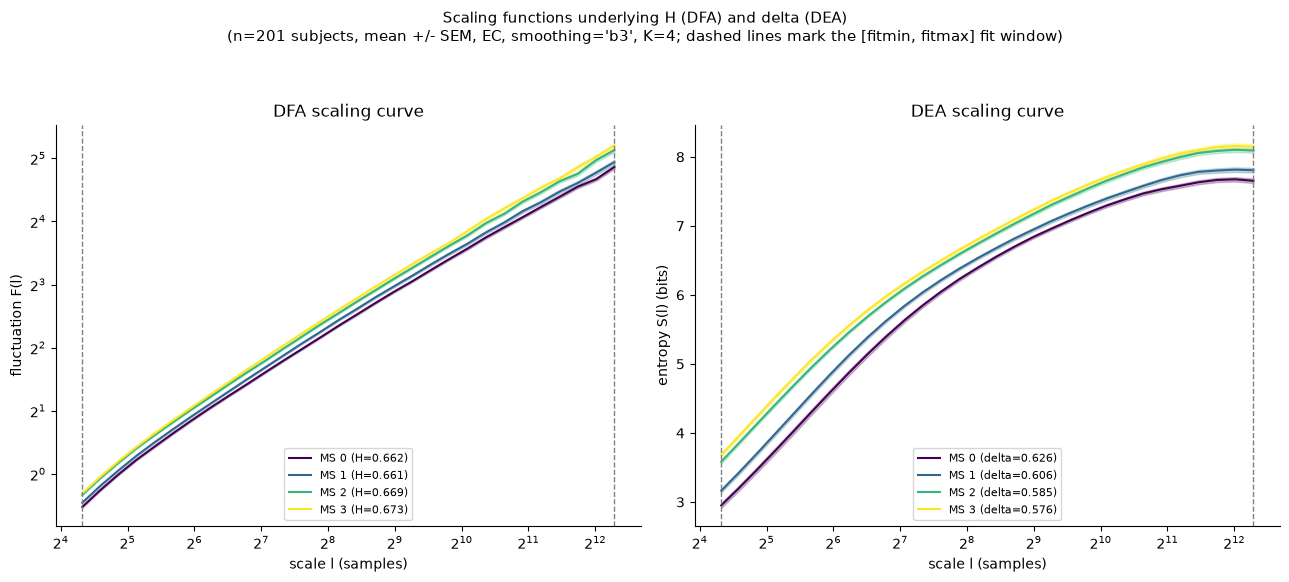

In [ ]:
colors = plt.cm.viridis(np.linspace(0, 1, K))

fig, axes = plt.subplots(1, 2, figsize=(13, 5.5))

# DFA: log-log fluctuation curve F(l)
ax = axes[0]
for k in range(K):
    mean_curve = fs_all[:, :, k].mean(axis=0)
    sem_curve = fs_all[:, :, k].std(axis=0, ddof=1) / np.sqrt(len(subjects))
    ax.plot(ls_scale, mean_curve, color=colors[k], 
            lw=1.5, label=f'MS {k} (H={hurst[:, k].mean():.3f})')
    ax.fill_between(ls_scale, mean_curve - sem_curve, mean_curve + sem_curve,
                     color=colors[k], alpha=0.25)
ax.set_xscale('log', base=2)
ax.set_yscale('log', base=2)
ax.axvline(p_scale['fitmin'], color='gray', ls='--', lw=1)
ax.axvline(p_scale['fitmax'], color='gray', ls='--', lw=1)
ax.set_xlabel('scale l (samples)')
ax.set_ylabel('fluctuation F(l)')
ax.set_title('DFA scaling curve')
ax.legend(fontsize=8)
ax.spines[['top', 'right']].set_visible(False)

# DEA: entropy vs log2(l) curve S(l)
ax = axes[1]
for k in range(K):
    mean_curve = ss_all[:, :, k].mean(axis=0)
    sem_curve = ss_all[:, :, k].std(axis=0, ddof=1) / np.sqrt(len(subjects))
    ax.plot(ls_scale, mean_curve, color=colors[k], 
            lw=1.5, label=f'MS {k} (delta={delta[:, k].mean():.3f})')
    ax.fill_between(ls_scale, mean_curve - sem_curve, mean_curve + sem_curve,
                     color=colors[k], alpha=0.25)
ax.set_xscale('log', base=2)
ax.axvline(p_scale['fitmin'], color='gray', ls='--', lw=1)
ax.axvline(p_scale['fitmax'], color='gray', ls='--', lw=1)
ax.set_xlabel('scale l (samples)')
ax.set_ylabel('entropy S(l) (bits)')
ax.set_title('DEA scaling curve')
ax.legend(fontsize=8)
ax.spines[['top', 'right']].set_visible(False)

fig.suptitle(f'Scaling functions underlying H (DFA) and delta (DEA)\n'
             f'(n={len(subjects)} subjects, mean +/- SEM, EC, smoothing={smoothing!r}, K={K}; '
             f'dashed lines mark the [fitmin, fitmax] fit window)',
             fontsize=11, y=1.05)
plt.tight_layout()
os.makedirs('figures', exist_ok=True)
plt.savefig('figures/hurst_vs_dea_scaling_functions.png', dpi=150, bbox_inches='tight')
plt.show()

## Agreement between H and delta per microstate

If microstate occurrence dynamics were a Gaussian self-affine (fractional Brownian
motion-like) process, points would fall on the `delta = H` diagonal for every
microstate. Systematic offset from the diagonal indicates non-Gaussian scaling that
DFA alone would not reveal.

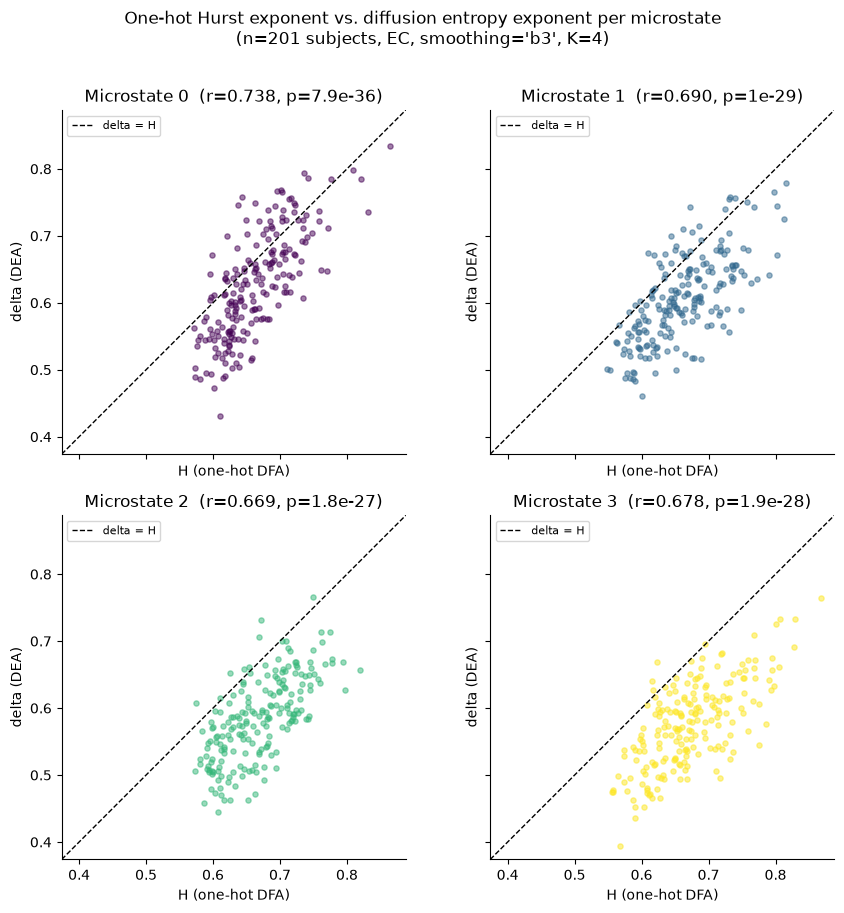

In [46]:
colors = plt.cm.viridis(np.linspace(0, 1, K))

fig, axes = plt.subplots(2, 2, figsize=(9, 9), sharex=True, sharey=True)

lims = (min(hurst.min(), delta.min()) - 0.02, max(hurst.max(), delta.max()) + 0.02)

for k, ax in enumerate(axes.flat):
    h_k, d_k = hurst[:, k], delta[:, k]
    r_pearson, p_pearson = pearsonr(h_k, d_k)
    ax.scatter(h_k, d_k, s=14, alpha=0.5, color=colors[k])
    ax.plot(lims, lims, 'k--', lw=1, label='delta = H')
    ax.set_xlim(lims)
    ax.set_ylim(lims)
    ax.set_aspect('equal')
    ax.set_title(f'Microstate {k}  (r={r_pearson:.3f}, p={p_pearson:.2g})')
    ax.set_xlabel('H (one-hot DFA)')
    ax.set_ylabel('delta (DEA)')
    ax.spines[['top', 'right']].set_visible(False)
    ax.legend(fontsize=8, loc='upper left')

fig.suptitle(f'One-hot Hurst exponent vs. diffusion entropy exponent per microstate\n'
             f'(n={len(subjects)} subjects, EC, smoothing={smoothing!r}, K={K})',
             fontsize=12, y=1.01)
plt.tight_layout()
os.makedirs('figures', exist_ok=True)
plt.savefig('figures/hurst_vs_dea_scatter.png', dpi=150, bbox_inches='tight')
plt.show()

## Paired comparison: does delta differ systematically from H?

Shapiro-Wilk (on the paired difference `delta_k - H_k`) decides between a paired
t-test and a Wilcoxon signed-rank test per microstate, matching the omnibus-test
convention used in `K-invariance.ipynb`. Effect size is Cohen's `d_z` for the
paired t-test, or the matched-pairs rank-biserial correlation for Wilcoxon.

In [47]:
def sig_stars(p):
    if p < 0.001:
        return '***'
    if p < 0.01:
        return '**'
    if p < 0.05:
        return '*'
    return 'ns'


alpha = 0.05
paired_results = {}
for k in range(K):
    diff = delta[:, k] - hurst[:, k]
    normal_diff = shapiro(diff).pvalue > alpha
    if normal_diff:
        stat, p = ttest_rel(delta[:, k], hurst[:, k])
        effect = diff.mean() / diff.std(ddof=1)  # Cohen's d_z
        test = 't-test'
    else:
        stat, p = wilcoxon(delta[:, k], hurst[:, k])
        n = len(diff)
        effect = 1 - (2 * stat) / (n * (n + 1) / 2)  # matched-pairs rank-biserial
        test = 'Wilcoxon'
    paired_results[k] = dict(test=test, statistic=stat, pvalue=p, effect=effect,
                              mean_diff=diff.mean(), median_diff=np.median(diff))
    print(f"Microstate {k}: {test:>8s}  stat={stat:.3f}  p={p:.4g} {sig_stars(p)}   "
          f"effect={effect:.3f}   mean(delta-H)={diff.mean():+.4f}   "
          f"median(delta-H)={np.median(diff):+.4f}")

Microstate 0:   t-test  stat=-9.600  p=3.443e-18 ***   effect=-0.677   mean(delta-H)=-0.0362   median(delta-H)=-0.0372
Microstate 1:   t-test  stat=-16.003  p=1.182e-37 ***   effect=-1.129   mean(delta-H)=-0.0549   median(delta-H)=-0.0526
Microstate 2:   t-test  stat=-24.805  p=6.073e-63 ***   effect=-1.750   mean(delta-H)=-0.0837   median(delta-H)=-0.0811
Microstate 3:   t-test  stat=-27.135  p=5.792e-69 ***   effect=-1.914   mean(delta-H)=-0.0964   median(delta-H)=-0.0964


## Summary

Pooled correlation across all subject x microstate pairs, and a grouped comparison
of mean `H` vs. mean `delta` per microstate.

Pooled (n=804 subject x microstate pairs): Pearson r=0.640 (p=1.1e-93), Spearman rho=0.639 (p=2.5e-93)
Pooled mean H = 0.6662, mean delta = 0.5984, mean(delta-H) = -0.0678


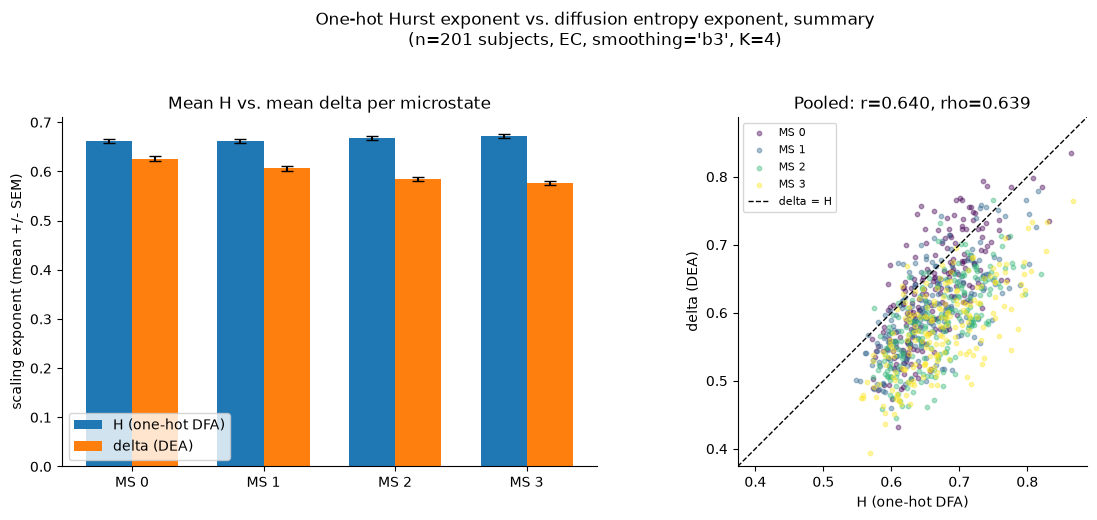

In [48]:
h_pooled = hurst.flatten()
d_pooled = delta.flatten()
r_all, p_all = pearsonr(h_pooled, d_pooled)
rho_all, p_rho_all = spearmanr(h_pooled, d_pooled)
print(f"Pooled (n={len(h_pooled)} subject x microstate pairs): "
      f"Pearson r={r_all:.3f} (p={p_all:.2g}), Spearman rho={rho_all:.3f} (p={p_rho_all:.2g})")
print(f"Pooled mean H = {h_pooled.mean():.4f}, mean delta = {d_pooled.mean():.4f}, "
      f"mean(delta-H) = {(d_pooled - h_pooled).mean():+.4f}")

fig, axes = plt.subplots(1, 2, figsize=(12, 5))

ax = axes[0]
x_pos = np.arange(K)
width = 0.35
h_mean, h_sem = hurst.mean(axis=0), hurst.std(axis=0, ddof=1) / np.sqrt(len(subjects))
d_mean, d_sem = delta.mean(axis=0), delta.std(axis=0, ddof=1) / np.sqrt(len(subjects))
ax.bar(x_pos - width / 2, h_mean, width, yerr=h_sem, capsize=4, label='H (one-hot DFA)', color='tab:blue')
ax.bar(x_pos + width / 2, d_mean, width, yerr=d_sem, capsize=4, label='delta (DEA)', color='tab:orange')
ax.set_xticks(x_pos)
ax.set_xticklabels([f'MS {k}' for k in range(K)])
ax.set_ylabel('scaling exponent (mean +/- SEM)')
ax.set_title('Mean H vs. mean delta per microstate')
ax.legend()
ax.spines[['top', 'right']].set_visible(False)

ax = axes[1]
lims = (min(h_pooled.min(), d_pooled.min()) - 0.02, max(h_pooled.max(), d_pooled.max()) + 0.02)
for k in range(K):
    ax.scatter(hurst[:, k], delta[:, k], s=10, alpha=0.4, color=colors[k], label=f'MS {k}')
ax.plot(lims, lims, 'k--', lw=1, label='delta = H')
ax.set_xlim(lims)
ax.set_ylim(lims)
ax.set_aspect('equal')
ax.set_xlabel('H (one-hot DFA)')
ax.set_ylabel('delta (DEA)')
ax.set_title(f'Pooled: r={r_all:.3f}, rho={rho_all:.3f}')
ax.legend(fontsize=8)
ax.spines[['top', 'right']].set_visible(False)

fig.suptitle(f'One-hot Hurst exponent vs. diffusion entropy exponent, summary\n'
             f'(n={len(subjects)} subjects, EC, smoothing={smoothing!r}, K={K})',
             fontsize=12, y=1.03)
plt.tight_layout()
os.makedirs('figures', exist_ok=True)
plt.savefig('figures/hurst_vs_dea_summary.png', dpi=150, bbox_inches='tight')
plt.show()

## Does the marginal density actually scale with H? A rescaling test

McCauley, Gunaratne & Bassler (2007) show that a process `x(t)` scales with exponent
`H` iff `x(t) =_d t^H x(1)` ("equal in distribution"), which forces the *marginal
density itself* into the scaling form
$$
f_1(x,t) = t^{-H} F(x/t^H).
$$
Concretely: rescale `x(t)` by `t^{-H}` at several different `t`, and the whole family
of marginal densities should collapse onto a single shape `F(u)`.

As emphasized in this notebook's introduction, this is a **necessary but not
sufficient** condition: ordinary memoryless Markov diffusions can be constructed to
satisfy exactly this density-scaling law for any `H` of your choosing (McCauley et
al.'s "scaling Gaussian Markov process"), so *passing* this test is not evidence of
genuine long-range dependence. *Failing* it, however, means the DFA-fitted `H` does
not even correspond to a properly self-affine process -- DFA only ever measures a
second-moment (fluctuation-function) scaling exponent, and says nothing about whether
the full density rescales consistently with that same `H`.

**Method:** for the one-hot random walk `y(t) = cumsum(indicator_k(t) - mean)` (the
same construction DFA operates on internally), draw increments
`dy = y(t0+t) - y(t0)` from many random start points `t0`, for several window lengths
`t` spanning the DFA fit range. Rescale each set of increments by `t^{-H}` using the
series' own DFA-estimated `H`, then overlay their histograms: collapse onto one curve
is consistent with density scaling; systematic spread or shape drift across `t` is
not. Laid out as a `K x 2` grid, one row per microstate:
- **left column**: the real microstate's own one-hot random walk, rescaled by its own
  empirical DFA `H` -- tests whether that `H` corresponds to genuine density scaling
  or is just a fluctuation-function slope with no such structure behind it.
- **right column**: a synthetic fBm control -- cumulative sum of `fGn(H, n)` seeded
  with that *same* microstate's `H` -- expected to collapse by construction. Since
  every microstate has a different empirical `H`, each gets its own matched fBm
  analogue rather than sharing one reference `H` across rows.

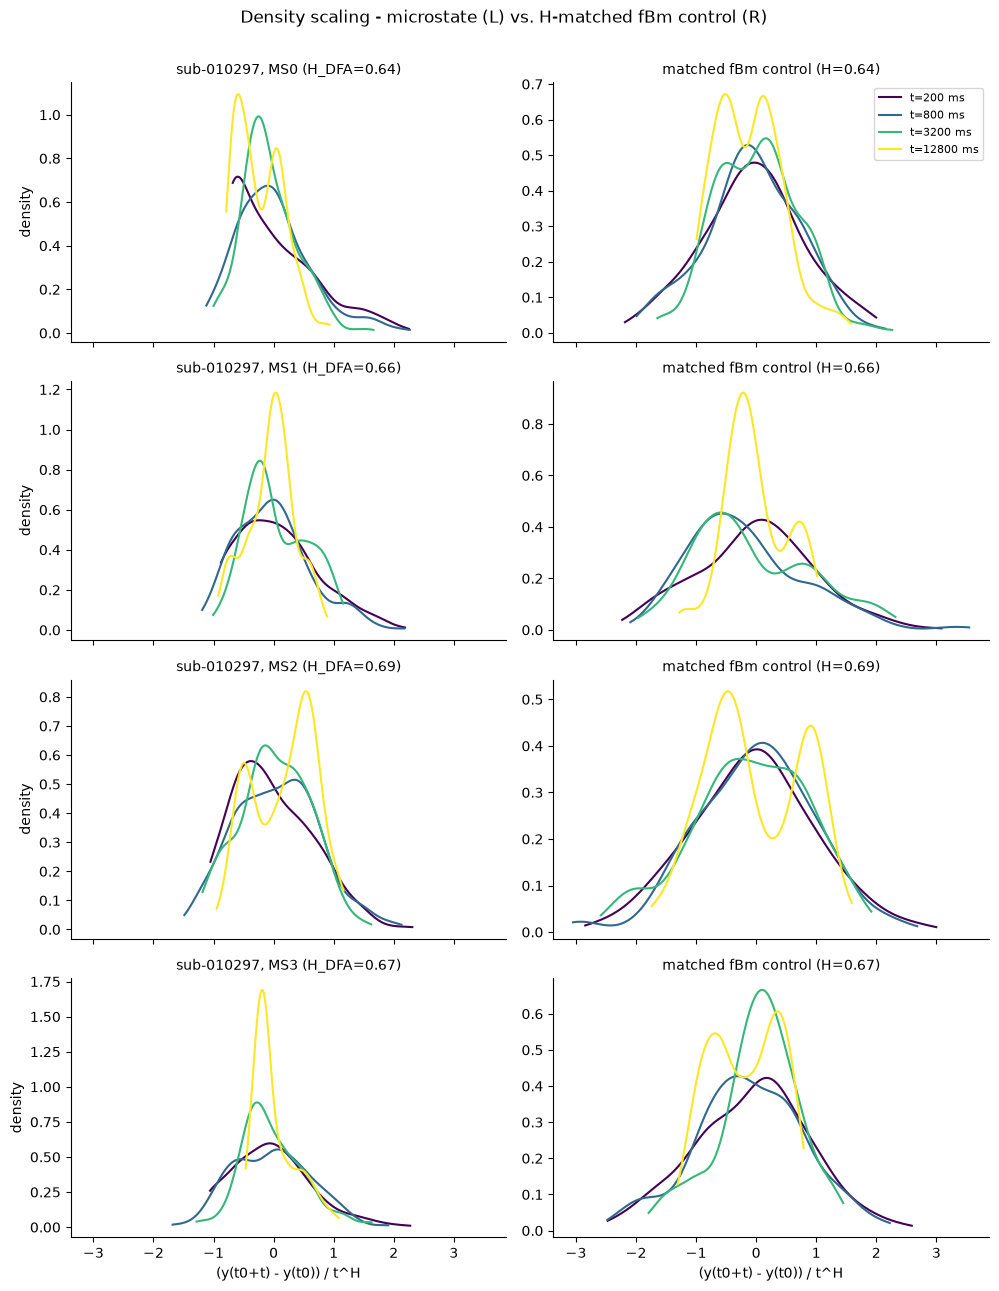


MS0: KS test, t=50 vs t=3200 rescaled: 
D=0.227, p=3.63e-07 (reject same distribution)

MS0 (fBm): KS test, t=50 vs t=3200 rescaled: 
D=0.150, p=0.00231 (reject same distribution)

MS1: KS test, t=50 vs t=3200 rescaled: 
D=0.200, p=1.16e-05 (reject same distribution)

MS1 (fBm): KS test, t=50 vs t=3200 rescaled: 
D=0.183, p=8.02e-05 (reject same distribution)

MS2: KS test, t=50 vs t=3200 rescaled: 
D=0.227, p=3.63e-07 (reject same distribution)

MS2 (fBm): KS test, t=50 vs t=3200 rescaled: 
D=0.110, p=0.053 (consistent with same distribution)

MS3: KS test, t=50 vs t=3200 rescaled: 
D=0.313, p=2.06e-13 (reject same distribution)

MS3 (fBm): KS test, t=50 vs t=3200 rescaled: 
D=0.193, p=2.56e-05 (reject same distribution)



In [66]:
from scipy.stats import ks_2samp, gaussian_kde

def collect_rescaled_increments(y, H, ts, n_starts=300, seed=0):
    """Increments dy = y(t0+t) - y(t0) over random start points t0, rescaled by
    t^-H, for each window length in ts. If y scales with exponent H, the
    resulting distributions should be (approximately) the same across t."""
    rng = np.random.default_rng(seed)
    n = len(y)
    out = {}
    for t in ts:
        max_start = n - t
        size = min(n_starts, max_start)
        starts = rng.integers(0, max_start, size=size)
        incr = y[starts + t] - y[starts]
        out[t] = incr / (t ** H)
    return out


def plot_density(ax, data, color, label, style='hist', bins=40, n_grid=200):
    """Draw one rescaled-increment distribution as either a step histogram or a
    kernel density estimate, depending on `style` ('hist' or 'kde')."""
    if style == 'hist':
        ax.hist(data, bins=bins, density=True, histtype='step', color=color,
                 lw=1.5, label=label)
    elif style == 'kde':
        kde = gaussian_kde(data)
        xs = np.linspace(data.min(), data.max(), n_grid)
        ax.plot(xs, kde(xs), color=color, lw=1.5, label=label)
    else:
        raise ValueError(f"unknown style {style!r}, expected 'hist' or 'kde'")


density_plot_style = 'kde'  # 'hist' or 'kde'

ts_rescale = [50, 200, 800, 3200]  # window lengths (samples) within DFA fit range

# Real microstate random walks: all K microstates of one example subject, each 
# with its own DFA-estimated H, paired with its own matched fBm control (same H) 
# one H-matched fBm analogue per microstate

#+++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++
example_subject = "sub-010297" 
#+++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++
fname_example = f"{data_path}/{example_subject}_EC_ms_{smoothing}_K{K}_ep00.npy"
x_example = np.load(fname_example)
n_synth = len(x_example)  # match fBm control length to the real microstate sequence
h_example = mstsa.hurst_exponents_dfa(x_example, **p_scale)

rescaled_real = {}
rescaled_synth = {}
for k in range(K):
    indicator_k = (x_example == k).astype(np.float64)
    y_k = np.cumsum(indicator_k - indicator_k.mean())
    rescaled_real[k] = collect_rescaled_increments(y_k, h_example[k], ts_rescale)

    noise_k = fGn(h_example[k], n_synth)
    noise_k = noise_k - noise_k.mean()
    y_synth_k = np.cumsum(noise_k)
    rescaled_synth[k] = collect_rescaled_increments(y_synth_k, h_example[k], ts_rescale, seed=k)

fig, axes = plt.subplots(K, 2, figsize=(10, 3.2 * K), sharex=True)
colors_t = plt.cm.viridis(np.linspace(0, 1, len(ts_rescale)))

for k in range(K):
    ax_real, ax_synth = axes[k, 0], axes[k, 1]

    for t, color in zip(ts_rescale, colors_t):
        label = f't={t*1000/fs:.0f} ms'
        plot_density(ax_real, rescaled_real[k][t], color, label, style=density_plot_style)
        plot_density(ax_synth, rescaled_synth[k][t], color, label, style=density_plot_style)

    ax_real.set_ylabel('density')
    ax_real.set_title(f'{example_subject}, MS{k} (H_DFA={h_example[k]:.2f})', 
                      fontsize=10)
    ax_synth.set_title(f'matched fBm control (H={h_example[k]:.2f})', 
                       fontsize=10)
    ax_real.spines[['top', 'right']].set_visible(False)
    ax_synth.spines[['top', 'right']].set_visible(False)

axes[0, 1].legend(fontsize=8)
axes[-1, 0].set_xlabel('(y(t0+t) - y(t0)) / t^H')
axes[-1, 1].set_xlabel('(y(t0+t) - y(t0)) / t^H')

fig.suptitle('Density scaling - microstate (L) vs. H-matched fBm control (R)',
             y=1.005)
plt.tight_layout()
os.makedirs('figures', exist_ok=True)
plt.savefig('figures/hurst_density_rescaling_test.png', dpi=150, 
            bbox_inches='tight')
plt.show()

# Quantitative check: std of the rescaled increments should be approx. constant 
# across t if density scaling holds. 
# KS test between the shortest and longest t should not be rejected
'''
print(f"{'case':>18s} {'t':>6s} {'std(rescaled)':>14s}")
for k in range(K):
    for t in ts_rescale:
        print(f"{'MS' + str(k):>18s} {t:6d} {rescaled_real[k][t].std():14.4f}")
    for t in ts_rescale:
        print(f"{'MS' + str(k) + ' (fBm)':>18s} {t:6d} "
              f"{rescaled_synth[k][t].std():14.4f}")
'''

print()
for k in range(K):
    stat, p = ks_2samp(rescaled_real[k][ts_rescale[0]], rescaled_real[k][ts_rescale[-1]])
    print(f"MS{k}: KS test, t={ts_rescale[0]} vs t={ts_rescale[-1]} rescaled: "
          f"\nD={stat:.3f}, p={p:.3g}"
          f"{' (reject same distribution)' if p < 0.05 
             else ' (consistent with same distribution)'}\n")
    stat, p = ks_2samp(rescaled_synth[k][ts_rescale[0]], rescaled_synth[k][ts_rescale[-1]])
    print(f"MS{k} (fBm): KS test, t={ts_rescale[0]} vs t={ts_rescale[-1]} rescaled: "
          f"\nD={stat:.3f}, p={p:.3g}"
          f"{' (reject same distribution)' if p < 0.05 
             else ' (consistent with same distribution)'}\n")